In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [2]:
from google.colab import drive

In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.initializers import Constant

In [5]:
import pickle

In [6]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
# Pre-download resources
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### for Distil-BERT model requirement

In [24]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [8]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [9]:
print(torch.cuda.is_available())

True


### coding part

In [10]:
# --- STEP 1: Google Drive Mount & Data Load ---
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Folder jahan tune save kiya tha
load_dir = '/content/drive/MyDrive/fake news project/V2_cleaned kaggle datasets'
file_path = os.path.join(load_dir, 'final_dataset.csv')

print(f"📂 Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    # Null values uda do (Safety check)
    df.dropna(subset=['content'], inplace=True)
    print(f"✅ Data Loaded! Total Rows: {len(df)}")
except Exception as e:
    print(f"❌ Error: File nahi mili! Kya path sahi hai? Error: {e}")

📂 Loading data from: /content/drive/MyDrive/fake news project/V2_cleaned kaggle datasets/final_dataset.csv
✅ Data Loaded! Total Rows: 166418


Applying 2 column in the datasets because we are training the model 2 ways onces without removing stopwords and one removing stopwords for better performance

In [12]:
# first method without removing the stopwords
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # URL hatao
    text = re.sub(r'<.*?>', '', text) # HTML hatao
    text = re.sub(r'[^a-z\s]', '', text) # Sirf alphabets
    return text

# second method by removing the stopwords
def advanced_clean(text):
    text = basic_clean(text)
    tokens = text.split()
    # Stopwords hatao aur Lemmatize karo
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned)

In [13]:
# now making 2 column in the dataset for 2 ways for training the model

# first column without nlp
df['content_raw'] = df['content'].apply(basic_clean)

# second column using nlp
df['content_cleaned'] = df['content'].apply(advanced_clean)

# First Making the Bi-directional LSTM Model by using nlp on dataset

In [ ]:
X = df['content_cleaned']
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vocab_size = 10000
max_len = 300

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Bi-directional LSTM model training phase

In [ ]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# model training start

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.7997 - loss: 0.4147 - val_accuracy: 0.8634 - val_loss: 0.2859
Epoch 2/10
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.8741 - loss: 0.2666 - val_accuracy: 0.8696 - val_loss: 0.2706
Epoch 3/10
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.8960 - loss: 0.2217 - val_accuracy: 0.8413 - val_loss: 0.3351
Epoch 4/10
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.8939 - loss: 0.2327 - val_accuracy: 0.8643 - val_loss: 0.3072


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

1041/1041 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8710 - loss: 0.2708
Test Accuracy: 0.8695469498634338


In [ ]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

1041/1041 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step


# confusion matrix


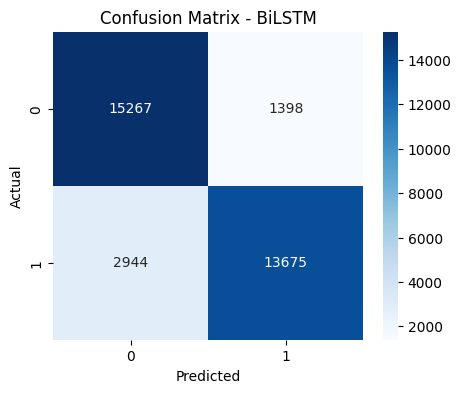

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM")
plt.show()

# classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88     16665
           1       0.91      0.82      0.86     16619

    accuracy                           0.87     33284
   macro avg       0.87      0.87      0.87     33284
weighted avg       0.87      0.87      0.87     33284



# Accuracy Graph

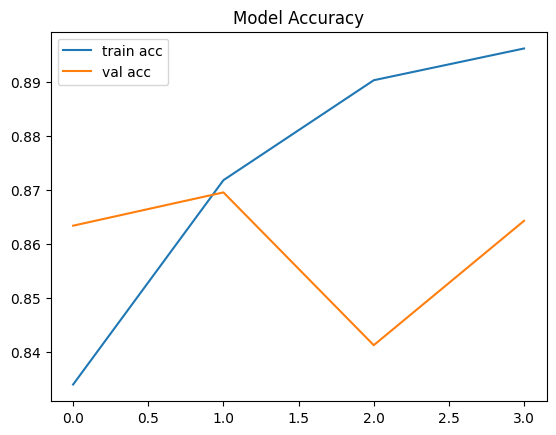

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# first saving the model

In [ ]:
# making the folder to save the model in that
save_dir = '/content/drive/MyDrive/fake news project/V2_dl_model_saved'
os.makedirs(save_dir, exist_ok=True)


In [ ]:
model_path = os.path.join(save_dir, "bi-direct_m1.keras")
model.save(model_path)
print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/fake news project/V2_dl_model_saved/bi-direct_m1.keras


# saving the tokenizer

In [ ]:
tokenizer_path = os.path.join(save_dir, "tokenizer.pkl")

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved")

Tokenizer saved


# now Making the Bi-directional LSTM Model by without using nlp on dataset

In [ ]:
X1 = df['content_raw']
y2 = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vocab_size = 20000
max_len = 400

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# model training

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=6,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/6
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 61s 35ms/step - accuracy: 0.7852 - loss: 0.4327 - val_accuracy: 0.8724 - val_loss: 0.2737
Epoch 2/6
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.8844 - loss: 0.2478 - val_accuracy: 0.8471 - val_loss: 0.3100
Epoch 3/6
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.8976 - loss: 0.2225 - val_accuracy: 0.8749 - val_loss: 0.2705
Epoch 4/6
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9266 - loss: 0.1638 - val_accuracy: 0.8710 - val_loss: 0.2909
Epoch 5/6
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.9402 - loss: 0.1357 - val_accuracy: 0.8691 - val_loss: 0.3325


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

1041/1041 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.8756 - loss: 0.2707
Test Accuracy: 0.8733325600624084


In [ ]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step


# confusion matrix

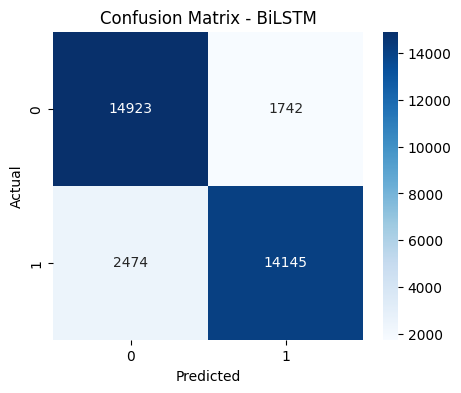

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM")
plt.show()

# classification matrix

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88     16665
           1       0.89      0.85      0.87     16619

    accuracy                           0.87     33284
   macro avg       0.87      0.87      0.87     33284
weighted avg       0.87      0.87      0.87     33284



# model accuracy

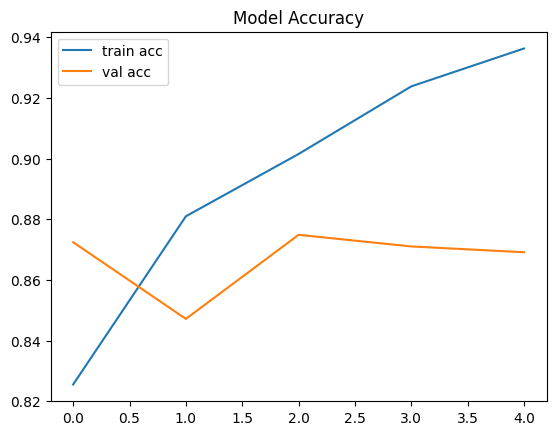

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# saving the model

In [ ]:
model_path = os.path.join(save_dir, "bi-direct_m2.keras")
model.save(model_path)
print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/fake news project/V2_dl_model_saved/bi-direct_m2.keras


### Using Distil-BERT MODEL

Preparing data

In [14]:
X = df['content_raw']   # using raw text only because heavy nlp is not needed in Distil-BERT
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

loading tokenizer

In [15]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenization function

In [16]:
MAX_LEN = 128

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

X_train_list = X_train.astype(str).tolist()
X_test_list = X_test.astype(str).tolist()

train_encodings = tokenize_function(X_train_list)
test_encodings = tokenize_function(X_test_list)

 PyTorch Dataset class

In [17]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx])
                for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, y_train)
test_dataset = NewsDataset(test_encodings, y_test)

Load DistilBERT model

In [18]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training arguments

In [22]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",      # ✅ changed
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True
)

Trainer

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

Train

In [24]:

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.235710,0.198683
2,0.215553,0.216141


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=16642, training_loss=0.20575761858079744, metrics={'train_runtime': 3530.7586, 'train_samples_per_second': 75.414, 'train_steps_per_second': 4.713, 'total_flos': 8817957326333952.0, 'train_loss': 0.20575761858079744, 'epoch': 2.0})

Predictions

In [25]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

confusion matrix

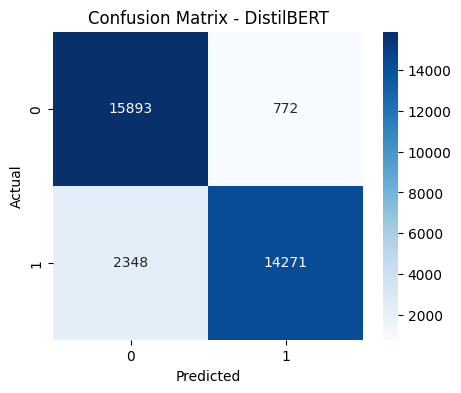

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

classification report

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     16665
           1       0.95      0.86      0.90     16619

    accuracy                           0.91     33284
   macro avg       0.91      0.91      0.91     33284
weighted avg       0.91      0.91      0.91     33284



saving the model

In [30]:
#giving the address where we have to save
save_dir = "/content/drive/MyDrive/fake news project/V2_dl_model_saved/distilbert_m1"
os.makedirs(save_dir, exist_ok=True)

In [31]:
trainer.save_model(save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saving the tokenizer

In [32]:
tokenizer.save_pretrained(save_dir)

('/content/drive/MyDrive/fake news project/V2_dl_model_saved/distilbert_m1/tokenizer_config.json',
 '/content/drive/MyDrive/fake news project/V2_dl_model_saved/distilbert_m1/tokenizer.json')

saving the json file to know whether 0-TRUE and 1-FAKE

In [33]:
import json

label_map = {"0": "True", "1": "Fake"}

with open(os.path.join(save_dir, "label_map.json"), "w") as f:
    json.dump(label_map, f)